# 📈 GRU — Bitcoin Price Forecasting

**Model:** Gated Recurrent Unit (GRU)  
**Task:** Multivariate time-series forecasting of Bitcoin closing price  
**Dataset:** Yahoo Finance — BTC-USD (auto-downloaded via `yfinance`)  

---
### Why GRU for Crypto?
GRUs are lighter than LSTMs (fewer parameters) while achieving comparable accuracy on financial sequences. Their update/reset gates let the model learn which historical price signals to retain or discard — crucial for noisy crypto data.

In [2]:
# ── 2. Imports ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


In [3]:
# ── 3. Download Bitcoin Data (2018 → present) ─────────────────────────────────
TICKER   = 'BTC-USD'
START    = '2018-01-01'
END      = '2024-12-31'
SEQ_LEN  = 60   # look-back window (days)
FORECAST = 1    # predict next day

df = yf.download(TICKER, start=START, end=END, auto_adjust=True)
df.dropna(inplace=True)
print(f"Shape: {df.shape}")
df.tail()

[*********************100%***********************]  1 of 1 completed

Shape: (2556, 5)


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-12-26,95795.515625,99884.570312,95137.882812,99297.695312,47054980873
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267
2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691


In [4]:
# ── 4. Feature Engineering ────────────────────────────────────────────────────
df = df[['Open','High','Low','Close','Volume']].copy()

# Technical indicators
df['Returns']    = df['Close'].pct_change()
df['MA_7']       = df['Close'].rolling(7).mean()
df['MA_21']      = df['Close'].rolling(21).mean()
df['Volatility'] = df['Returns'].rolling(7).std()
df['RSI']        = 100 - (100 / (1 + df['Returns'].clip(lower=0).rolling(14).mean() /
                                   (-df['Returns'].clip(upper=0)).rolling(14).mean()))
df['Price_Range']= (df['High'] - df['Low']) / df['Close']
df.dropna(inplace=True)

FEATURES = ['Open','High','Low','Close','Volume','Returns','MA_7','MA_21',
            'Volatility','RSI','Price_Range']
TARGET   = 'Close'

print(f"Features used: {FEATURES}")
print(f"Dataset shape after feature engineering: {df.shape}")

Features used: ['Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'MA_7', 'MA_21', 'Volatility', 'RSI', 'Price_Range']
Dataset shape after feature engineering: (2536, 11)


In [5]:
# ── 5. Scale & Build Sequences ────────────────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[FEATURES])
y_scaled = scaler_y.fit_transform(df[[TARGET]])

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

# Train / Val / Test split (70 / 15 / 15)
n        = len(X_seq)
tr_end   = int(n * 0.70)
va_end   = int(n * 0.85)

X_train, y_train = X_seq[:tr_end],   y_seq[:tr_end]
X_val,   y_val   = X_seq[tr_end:va_end], y_seq[tr_end:va_end]
X_test,  y_test  = X_seq[va_end:],   y_seq[va_end:]

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")

Train: (1733, 60, 11)  |  Val: (371, 60, 11)  |  Test: (372, 60, 11)


In [6]:
# ── 6. Build GRU Model ────────────────────────────────────────────────────────
tf.random.set_seed(42)

model = Sequential([
    GRU(128, return_sequences=True,
        input_shape=(SEQ_LEN, len(FEATURES))),
    BatchNormalization(),
    Dropout(0.2),

    GRU(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    GRU(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.15),

    Dense(16, activation='relu'),
    Dense(1)
], name='GRU_Crypto')

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='huber',
    metrics=['mae']
)

model.summary()

Model: "GRU_Crypto"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,241 (399.38 KB)

 Trainable params: 101,793 (397.63 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# ── 7. Train ──────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.1230 - mae: 0.3888 - val_loss: 0.0163 - val_mae: 0.1735 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0618 - mae: 0.2765 - val_loss: 0.0074 - val_mae: 0.1119 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0465 - mae: 0.2386 - val_loss: 0.0091 - val_mae: 0.1240 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0379 - mae: 0.2172 - val_loss: 0.0066 - val_mae: 0.1034 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0282 - mae: 0.1860 - val_loss: 0.0062 - val_mae: 0.1019 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0226 - mae: 0.1675 - val_loss: 0.0056 - val_mae: 0.0968 - learning_rate: 0.0010
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0189 - mae: 0.1507 - val_loss: 0.0085 - val_mae: 0.1200 - learning_rate: 0.0010
E

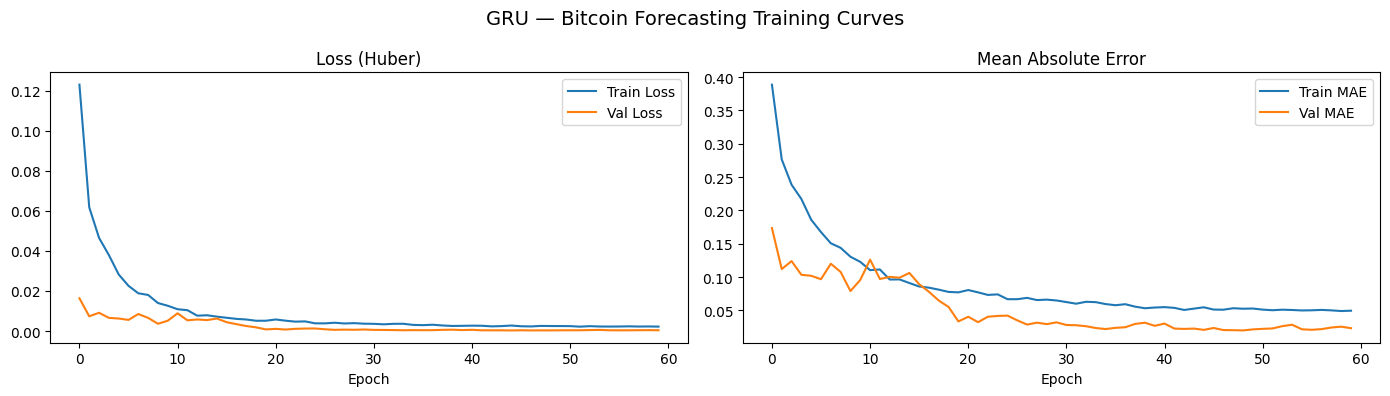

In [8]:
# ── 8. Training Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (Huber)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('GRU — Bitcoin Forecasting Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# ── 9. Evaluate on Test Set ───────────────────────────────────────────────────
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("─" * 40)
print(f"  MAE  : ${mae:,.2f}")
print(f"  RMSE : ${rmse:,.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")
print("─" * 40)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
────────────────────────────────────────
  MAE  : $10,154.20
  RMSE : $14,453.33
  MAPE : 13.56%
  R²   : 0.0481
────────────────────────────────────────


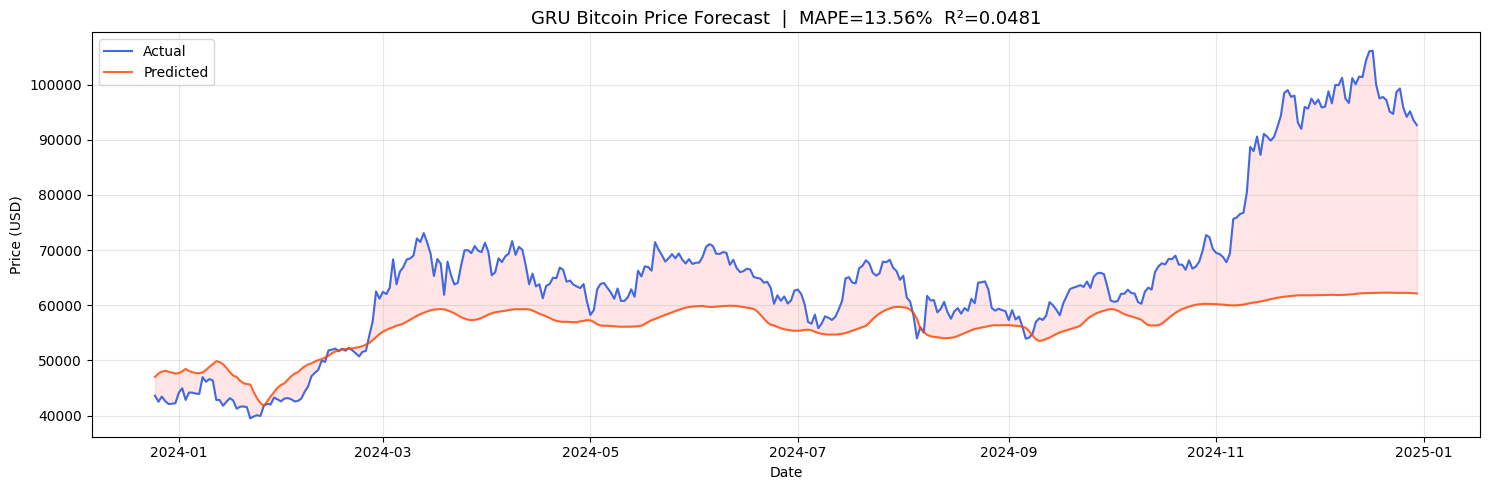

In [10]:
# ── 10. Actual vs Predicted Plot ──────────────────────────────────────────────
test_dates = df.index[va_end + SEQ_LEN:]

plt.figure(figsize=(15, 5))
plt.plot(test_dates, y_true, label='Actual',    color='royalblue', linewidth=1.5)
plt.plot(test_dates, y_pred, label='Predicted', color='orangered', linewidth=1.5, alpha=0.8)
plt.fill_between(test_dates, y_true, y_pred, alpha=0.1, color='red')
plt.title(f'GRU Bitcoin Price Forecast  |  MAPE={mape:.2f}%  R²={r2:.4f}', fontsize=13)
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

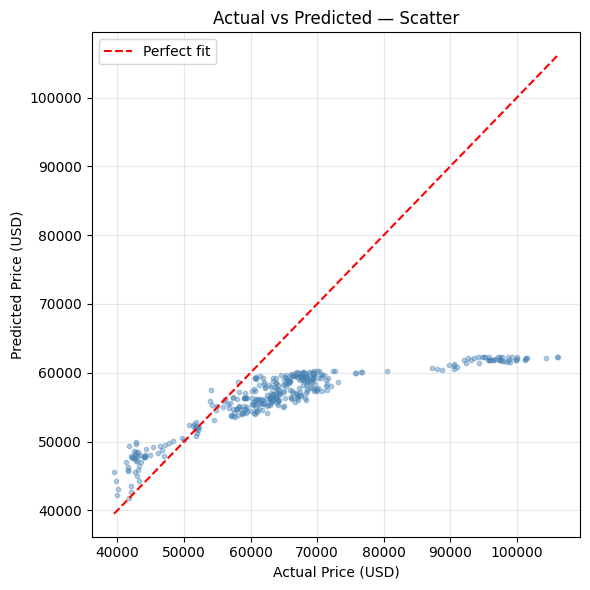

In [11]:
# ── 11. Scatter — Actual vs Predicted ────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.4, color='steelblue', s=10)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Price (USD)'); plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted — Scatter')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ── 12. Directional Accuracy (Up / Down) ─────────────────────────────────────
actual_dir = np.sign(np.diff(y_true))
pred_dir   = np.sign(np.diff(y_pred))
dir_acc    = np.mean(actual_dir == pred_dir) * 100
print(f"Directional Accuracy: {dir_acc:.2f}%  (predicting price direction correctly)")

Directional Accuracy: 52.02%  (predicting price direction correctly)
